In [5]:
import numpy as np  # Importe NumPy pour manipuler les tableaux et effectuer les calculs matriciels.
import matplotlib.pyplot as plt  # Importe matplotlib pour afficher des graphes.

Paramètres appris :
[[3.02943842]
 [1.90842474]
 [3.99981264]]


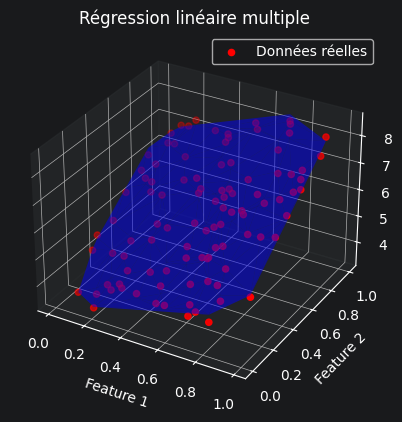

In [6]:
def multiple_lineare_regression(x_test, y_test, iterations, alpha):  # Définit une fonction de régression linéaire multiple avec descente de gradient.
    m = x_test.shape[0]  # Récupère le nombre d'exemples dans le jeu de données.

    colonne = np.ones((m, 1))  # Crée une colonne de 1 pour intégrer le biais dans le modèle.
    X_b = np.hstack((colonne, x_test))  # Concatène la colonne de biais avec les variables d'entrée.

    n_caract = X_b.shape[1]  # Récupère le nombre total de paramètres à apprendre.
    Z = np.zeros((n_caract, 1))  # Initialise tous les paramètres du modèle à 0.
    loses = []  # Initialise une liste pour stocker l'évolution de l'erreur.

    for i in range(iterations):  # Répète l'entraînement pendant le nombre d'itérations demandé.
        y_prediction = X_b @ Z  # Calcule les prédictions du modèle.

        erreur = y_prediction - y_test  # Calcule l'écart entre les prédictions et les vraies valeurs.

        gradient = (1 / m) * (X_b.T @ erreur)  # Calcule le gradient de la fonction de coût.

        loses.append(np.linalg.norm(erreur))  # Enregistre la norme de l'erreur à cette itération.

        Z -= alpha * gradient  # Met à jour les paramètres avec la descente de gradient.

    return Z, loses  # Retourne les paramètres finaux et la liste des erreurs.

np.random.seed(0)  # Fixe la graine aléatoire pour rendre les résultats reproductibles.
x_test = np.random.rand(100, 2)  # Génère 100 exemples avec 2 variables explicatives.
y_test = 3 + 2 * x_test[:, [0]] + 4 * x_test[:, [1]] + np.random.randn(100, 1) * 0.2  # Génère une cible linéaire bruitée à partir des deux variables.

iterations = 1000  # Définit le nombre d'itérations pour l'entraînement.
alpha = 0.1  # Définit le taux d'apprentissage de la descente de gradient.

Z, loses = multiple_lineare_regression(x_test, y_test, iterations, alpha)  # Entraîne le modèle et récupère les paramètres appris ainsi que les erreurs.

print("Paramètres appris :")  # Affiche un texte d'introduction.
print(Z)  # Affiche les coefficients appris par le modèle.

colonne = np.ones((x_test.shape[0], 1))  # Crée à nouveau une colonne de 1 pour préparer les données au calcul des prédictions.
X_b = np.hstack((colonne, x_test))  # Reconstitue la matrice des entrées avec la colonne de biais.
y_prediction = X_b @ Z  # Calcule les prédictions finales du modèle.

fig = plt.figure()  # Crée une nouvelle figure pour l'affichage 3D.
ax = fig.add_subplot(111, projection='3d')  # Ajoute un axe 3D à la figure.

ax.scatter(x_test[:, 0], x_test[:, 1], y_test.flatten(), color='red', label='Données réelles')  # Affiche les vraies données sous forme de points rouges.
ax.plot_trisurf(x_test[:, 0], x_test[:, 1], y_prediction.flatten(), color='blue', alpha=0.5)  # Affiche le plan de régression appris sous forme de surface bleue.

ax.set_xlabel('Feature 1')  # Définit le label de l'axe X.
ax.set_ylabel('Feature 2')  # Définit le label de l'axe Y.
ax.set_zlabel('Target')  # Définit le label de l'axe Z.
ax.set_title('Régression linéaire multiple')  # Définit le titre du graph.
ax.legend()  # Affiche la légende du graphique.
plt.show()  # Affiche le graphique 3D.